In [23]:
import torch
import numpy as np
import pandas as pd
import seaborn as sns
from cycler import cycler
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter
from sklearn.ensemble import RandomForestRegressor
from transformers import AutoTokenizer, AutoModelForCausalLM

from sdscm import plot_dag_from_sample_space, sample_sequences, format_sequences_as_dataframe, sample_counterfactual_sequences
from gb10.uma import setup_gb10, gb10_safe_sample_sequences

# Load language model

In [2]:
tokenizer = AutoTokenizer.from_pretrained('gpt2')
tokenizer.pad_token = tokenizer.eos_token
model = AutoModelForCausalLM.from_pretrained('gpt2')

/usr/local/anaconda3/envs/llm/lib/python3.11/site-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [ ]:
# GB10/DGX Spark unified memory setup
setup_gb10(model)

# Define confounder SD-SCM

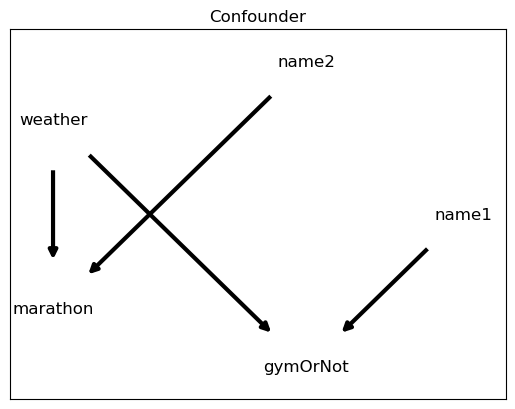

In [3]:
confounder_sample_space = [
    {
        'prefix': 'My name is ',
        'suffix': '.',
        'candidate_set': ['John', 'Jane', 'Alice', 'Bob', 'Charlie'],
        'intervention_choice': None,
        'parent_indices': None,
        'exogenous': True,
        'variable_name': 'name1',
    },
    {
        'prefix': 'I know someone named ',
        'suffix': '.',
        'candidate_set': ['John', 'Jane', 'Alice', 'Bob', 'Charlie'],
        'intervention_choice': None,
        'parent_indices': None,
        'exogenous': True,
        'variable_name': 'name2',
    },
    {
        'prefix': 'Conditions are ',
        'suffix': ' outside in the open air.',
        'candidate_set': ['sunny', 'rainy', 'snowy', 'cold', 'hot'],
        'intervention_choice': None,
        'parent_indices': None,
        'exogenous': False,
        'variable_name': 'weather',
    },
    {
        'prefix': 'After this, my marathon personal best will ',
        'suffix': '.',
        'candidate_set': ['improve', 'worsen'],
        'intervention_choice': None,
        'parent_indices': [1, 2],
        'exogenous': False,
        'variable_name': 'marathon',
    },
    {
        'prefix': 'I owe it to myself to go ',
        'suffix': '.',
        'candidate_set': ['to the gym', 'for a run outside'],
        'intervention_choice': None,
        'parent_indices': [0, 2],
        'exogenous': False,
        'variable_name': 'gymOrNot',
    },
]

plot_dag_from_sample_space(sequence_sample_space=confounder_sample_space, title='Confounder')

## Sample confounder data

In [4]:
np.random.seed(1)
torch.manual_seed(1)

num_samples = 1000
name_of_intervention = 'gymOrNot'
name_of_outcome = 'marathon'
all_covariates = [setup_dict['variable_name'] for setup_dict in confounder_sample_space]

confounder_samples = sample_sequences(
    model=model,
    tokenizer=tokenizer,
    sequence_sample_space=confounder_sample_space,
    num_samples=num_samples
)

df_samples_confounder = format_sequences_as_dataframe(sequences=confounder_samples, name_of_intervention=name_of_intervention, name_of_outcome=name_of_outcome, save_logprobs=True)
with pd.option_context('display.max_colwidth', None):
    display(df_samples_confounder[['sampled_text']])
    display(df_samples_confounder[all_covariates])

print('Sampling counterfactuals...')
np.random.seed(3)
torch.manual_seed(3)
index_of_intervention = np.where([setup_dict['variable_name'] == name_of_intervention for setup_dict in confounder_sample_space])[0][0]
evidence_indices = [np.where([setup_dict['variable_name'] == 'weather' for setup_dict in confounder_sample_space])[0][0]]
confounder_cf_samples_do_0 = sample_counterfactual_sequences(
    model=model,
    tokenizer=tokenizer,
    sequence_sample_space=confounder_sample_space,
    samples=confounder_samples,
    evidence_indices=evidence_indices,
    index_of_intervention=index_of_intervention,
    intervention_choice=0
)
confounder_cf_samples_do_1 = sample_counterfactual_sequences(
    model=model,
    tokenizer=tokenizer,
    sequence_sample_space=confounder_sample_space,
    samples=confounder_samples,
    evidence_indices=evidence_indices,
    index_of_intervention=index_of_intervention,
    intervention_choice=1
)
df_confounder_cf_samples_do_0 = format_sequences_as_dataframe(sequences=confounder_cf_samples_do_0, name_of_intervention=name_of_intervention, name_of_outcome=name_of_outcome)
df_confounder_cf_samples_do_1 = format_sequences_as_dataframe(sequences=confounder_cf_samples_do_1, name_of_intervention=name_of_intervention, name_of_outcome=name_of_outcome)
print('Done.')

100%|██████████| 1000/1000 [12:55<00:00,  1.29it/s]


,sampled_text
0,"My name is Bob. I know someone named John. Conditions are hot outside in the open air. After this, my marathon personal best will worsen. I owe it to myself to go for a run outside."
1,"My name is Alice. I know someone named Bob. Conditions are sunny outside in the open air. After this, my marathon personal best will worsen. I owe it to myself to go to the gym."
2,"My name is Jane. I know someone named John. Conditions are cold outside in the open air. After this, my marathon personal best will worsen. I owe it to myself to go to the gym."
3,"My name is Jane. I know someone named Bob. Conditions are sunny outside in the open air. After this, my marathon personal best will worsen. I owe it to myself to go to the gym."
4,"My name is Jane. I know someone named John. Conditions are snowy outside in the open air. After this, my marathon personal best will worsen. I owe it to myself to go for a run outside."
...,...
995,"My name is Alice. I know someone named Bob. Conditions are hot outside in the open air. After this, my marathon personal best will worsen. I owe it to myself to go to the gym."
996,"My name is Jane. I know someone named Bob. Conditions are hot outside in the open air. After this, my marathon personal best will worsen. I owe it to myself to go for a run outside."
997,"My name is Alice. I know someone named Jane. Conditions are sunny outside in the open air. After this, my marathon personal best will worsen. I owe it to myself to go to the gym."
998,"My name is Jane. I know someone named Jane. Conditions are hot outside in the open air. After this, my marathon personal best will worsen. I owe it to myself to go for a run outside."


,name1,name2,weather,marathon,gymOrNot
0,3,0,4,1,1
1,2,3,0,1,0
2,1,0,3,1,0
3,1,3,0,1,0
4,1,0,2,1,1
...,...,...,...,...,...
995,2,3,4,1,0
996,1,3,4,1,1
997,2,1,0,1,0
998,1,1,4,1,1


Sampling counterfactuals...


100%|██████████| 1000/1000 [02:00<00:00,  8.32it/s]

Done.


# Define collider SD-SCM

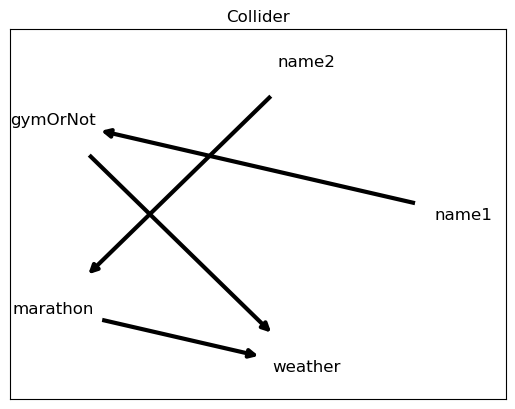

In [5]:
collider_sample_space = [
    {
        'prefix': 'My name is ',
        'suffix': '.',
        'candidate_set': ['John', 'Jane', 'Alice', 'Bob', 'Charlie'],
        'intervention_choice': None,
        'parent_indices': None,
        'exogenous': True,
        'variable_name': 'name1',
    },
    {
        'prefix': 'I know someone named ',
        'suffix': '.',
        'candidate_set': ['John', 'Jane', 'Alice', 'Bob', 'Charlie'],
        'intervention_choice': None,
        'parent_indices': None,
        'exogenous': True,
        'variable_name': 'name2',
    },
    {
        'prefix': 'I owe it to myself to go ',
        'suffix': '.',
        'candidate_set': ['to the gym', 'for a run outside'],
        'intervention_choice': None,
        'parent_indices': [0],
        'exogenous': False,
        'variable_name': 'gymOrNot',
    },
    {
        'prefix': 'After this, my marathon personal best will ',
        'suffix': '.',
        'candidate_set': ['improve', 'worsen'],
        'intervention_choice': None,
        'parent_indices': [1],
        'exogenous': False,
        'variable_name': 'marathon',
    },
    {
        'prefix': 'Conditions are ',
        'suffix': ' outside in the open air.',
        'candidate_set': ['sunny', 'rainy', 'snowy', 'cold', 'hot'],
        'intervention_choice': None,
        'parent_indices': [2, 3],
        'exogenous': False,
        'variable_name': 'weather',
    },
]

plot_dag_from_sample_space(sequence_sample_space=collider_sample_space, title='Collider')

## Sample collider data

In [6]:
np.random.seed(1)
torch.manual_seed(1)

num_samples = 1000
name_of_intervention = 'gymOrNot'
name_of_outcome = 'marathon'
all_covariates = [setup_dict['variable_name'] for setup_dict in collider_sample_space]

collider_samples = sample_sequences(
    model=model,
    tokenizer=tokenizer,
    sequence_sample_space=collider_sample_space,
    num_samples=num_samples
)

df_samples_collider = format_sequences_as_dataframe(sequences=collider_samples, name_of_intervention=name_of_intervention, name_of_outcome=name_of_outcome, save_logprobs=True)
with pd.option_context('display.max_colwidth', None):
    display(df_samples_collider[['sampled_text']])
    display(df_samples_collider[all_covariates])

print('Sampling counterfactuals...')
np.random.seed(3)
torch.manual_seed(3)
index_of_intervention = np.where([setup_dict['variable_name'] == name_of_intervention for setup_dict in collider_sample_space])[0][0]
collider_cf_samples_do_0 = sample_counterfactual_sequences(
    model=model,
    tokenizer=tokenizer,
    sequence_sample_space=collider_sample_space,
    samples=collider_samples,
    evidence_indices=[],
    index_of_intervention=index_of_intervention,
    intervention_choice=0
)
collider_cf_samples_do_1 = sample_counterfactual_sequences(
    model=model,
    tokenizer=tokenizer,
    sequence_sample_space=collider_sample_space,
    samples=collider_samples,
    evidence_indices=[],
    index_of_intervention=index_of_intervention,
    intervention_choice=1
)
df_collider_cf_samples_do_0 = format_sequences_as_dataframe(sequences=collider_cf_samples_do_0, name_of_intervention=name_of_intervention, name_of_outcome=name_of_outcome)
df_collider_cf_samples_do_1 = format_sequences_as_dataframe(sequences=collider_cf_samples_do_1, name_of_intervention=name_of_intervention, name_of_outcome=name_of_outcome)
print('Done.')

100%|██████████| 1000/1000 [13:37<00:00,  1.22it/s]


,sampled_text
0,"My name is Bob. I know someone named John. I owe it to myself to go for a run outside. After this, my marathon personal best will worsen. Conditions are cold outside in the open air."
1,"My name is Alice. I know someone named Bob. I owe it to myself to go to the gym. After this, my marathon personal best will worsen. Conditions are hot outside in the open air."
2,"My name is Jane. I know someone named John. I owe it to myself to go to the gym. After this, my marathon personal best will worsen. Conditions are sunny outside in the open air."
3,"My name is Jane. I know someone named Bob. I owe it to myself to go to the gym. After this, my marathon personal best will worsen. Conditions are cold outside in the open air."
4,"My name is Jane. I know someone named John. I owe it to myself to go to the gym. After this, my marathon personal best will worsen. Conditions are rainy outside in the open air."
...,...
995,"My name is Alice. I know someone named Bob. I owe it to myself to go for a run outside. After this, my marathon personal best will worsen. Conditions are sunny outside in the open air."
996,"My name is Jane. I know someone named Bob. I owe it to myself to go for a run outside. After this, my marathon personal best will worsen. Conditions are snowy outside in the open air."
997,"My name is Alice. I know someone named Jane. I owe it to myself to go to the gym. After this, my marathon personal best will worsen. Conditions are sunny outside in the open air."
998,"My name is Jane. I know someone named Jane. I owe it to myself to go for a run outside. After this, my marathon personal best will worsen. Conditions are rainy outside in the open air."


,name1,name2,gymOrNot,marathon,weather
0,3,0,1,1,3
1,2,3,0,1,4
2,1,0,0,1,0
3,1,3,0,1,3
4,1,0,0,1,1
...,...,...,...,...,...
995,2,3,1,1,0
996,1,3,1,1,2
997,2,1,0,1,0
998,1,1,1,1,1


Sampling counterfactuals...


100%|██████████| 1000/1000 [05:58<00:00,  2.79it/s]

Done.


# Compare distributions and estimation

Setting: Confounder
	SATE: 0.0
	Observational ATE: 0.1735917938191065
	SATE RF prediction with ['weather', 'gymOrNot']: 0.004177856289361169
	SATE RF prediction with ['gymOrNot']: 0.17280943748470418
Setting: Collider
	SATE: 0.0
	Observational ATE: -0.08942779948633027
	SATE RF prediction with ['weather', 'gymOrNot']: -0.13093770153938325
	SATE RF prediction with ['gymOrNot']: -0.08132339131543989


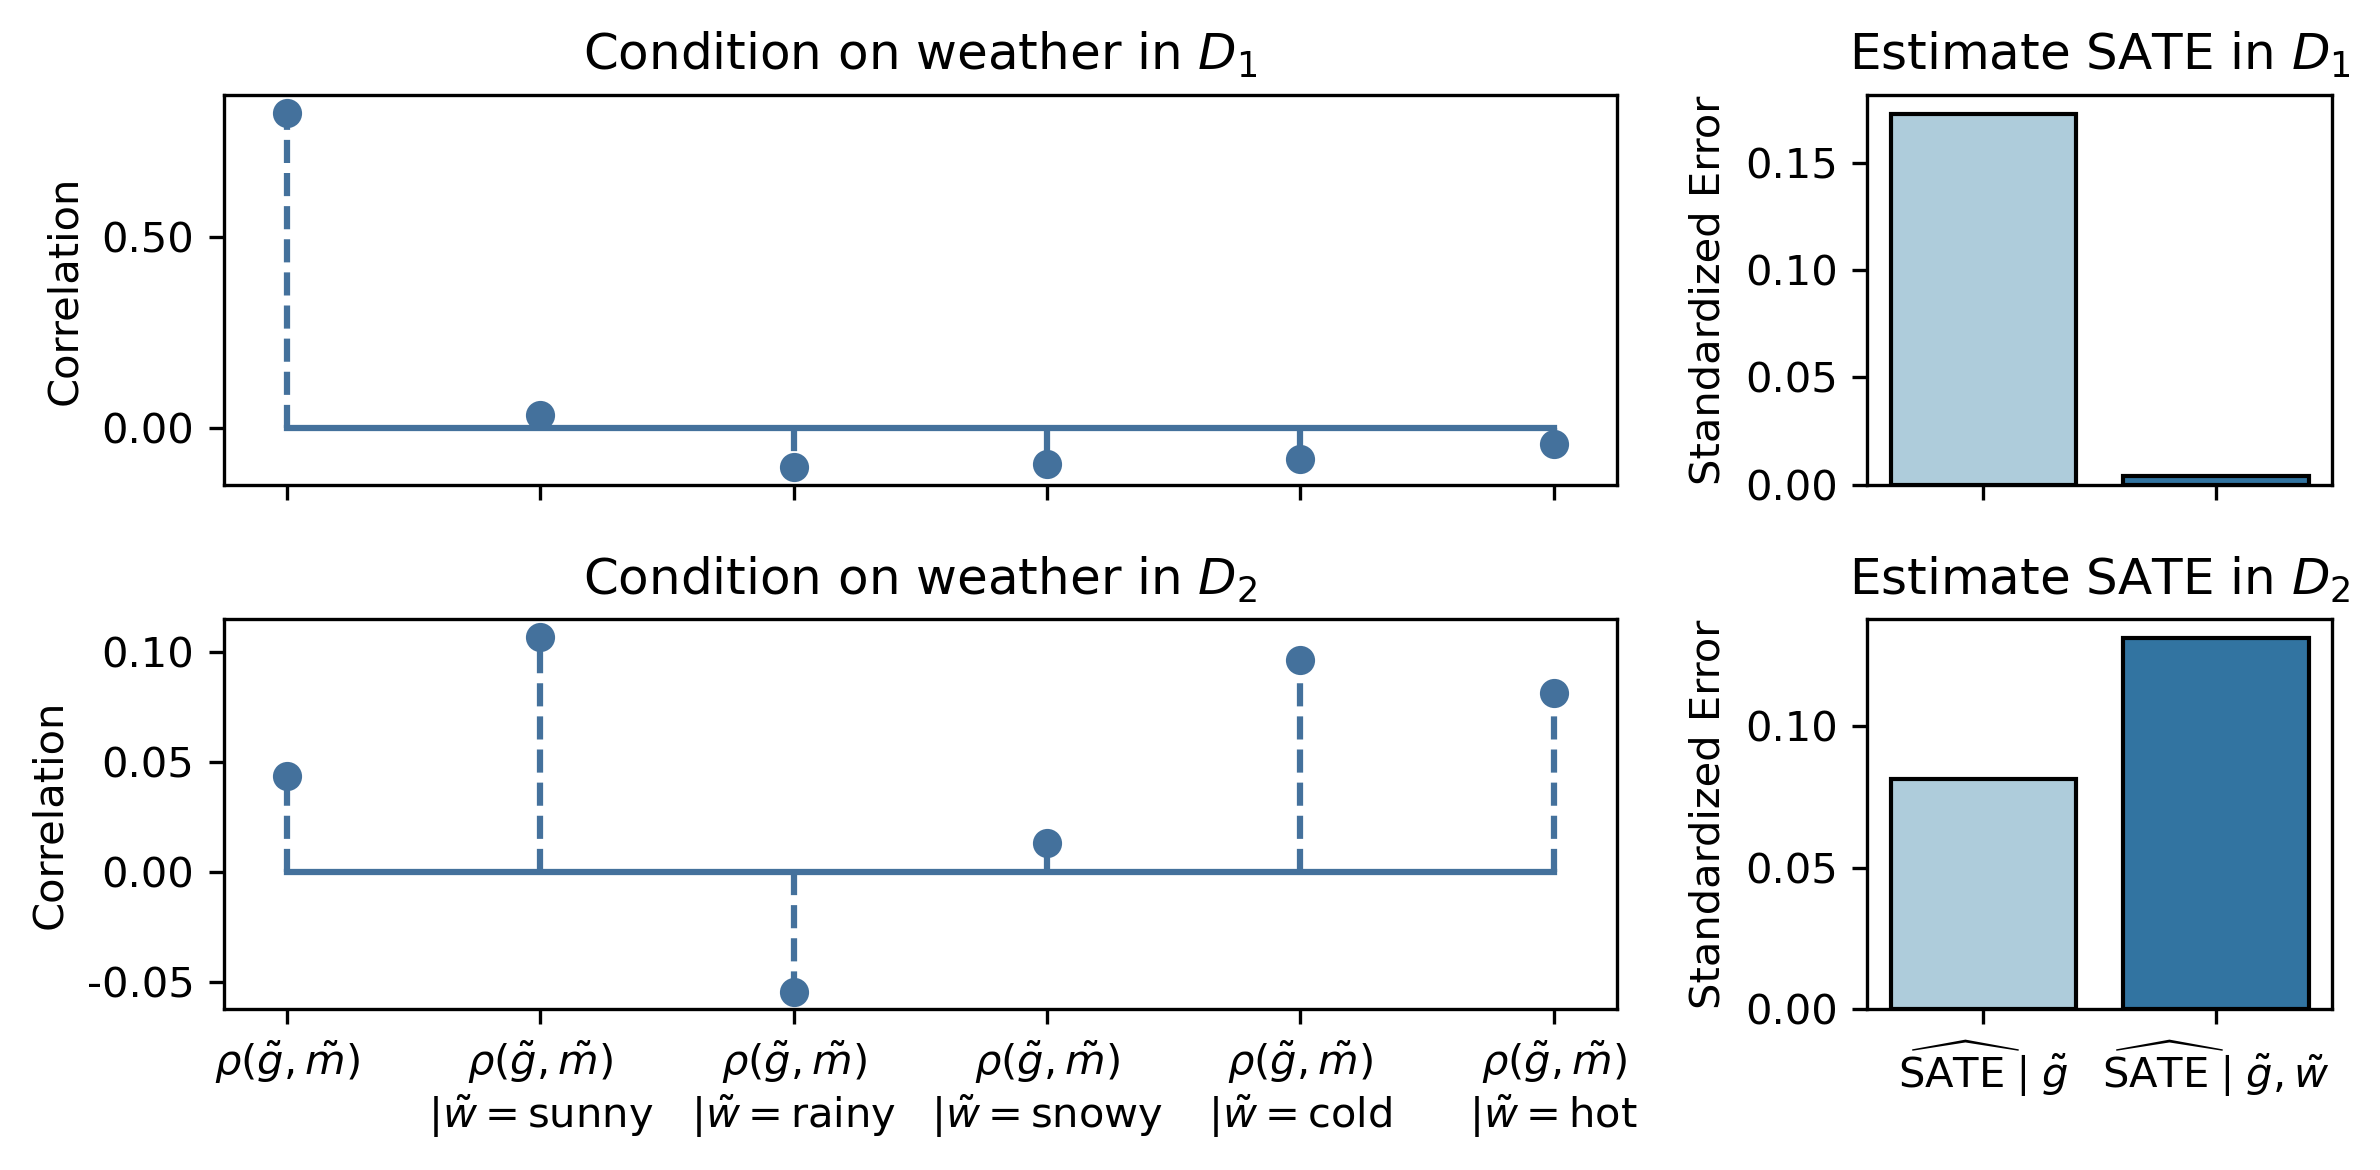

In [22]:
sns.reset_orig()
plt.rcParams['axes.prop_cycle'] = cycler(color=['#AEC5D3', '#44719C'])
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(8, 4), sharey=False, sharex='col', dpi=300, width_ratios=(6, 2))
axes = axes.ravel()
x_var = 'P(gymOrNot=1)'
y_var = 'P(marathon=1)'
settings = [
    ('confounder', confounder_sample_space, df_samples_confounder),
    ('collider', collider_sample_space, df_samples_collider)
]
correlation_dicts = []
for i, (setting_name, sample_space, df) in enumerate(settings):
    condition_names = [
        name for setup_dict in sample_space 
        for name in setup_dict['candidate_set'] 
        if setup_dict['variable_name'] == 'weather'
    ]
    original_x = df[x_var].values
    original_y = df[y_var].values
    original_name = r'$\rho(\tilde{g}, \tilde{m})$'
    corr_coefs = {original_name: np.corrcoef(x=original_x, y=original_y)[0, 1]}
    for condition in sorted(df['weather'].unique()):
        which_rows = df['weather'] == condition
        x_vals = df[which_rows][x_var].values
        y_vals = df[which_rows][y_var].values
        condition_name = original_name + '\n' + r'$|\tilde{w}=$' + f'{condition_names[condition]}'
        corr_coefs[condition_name] = np.corrcoef(x=x_vals, y=y_vals)[0, 1]
    ticks = list(range(len(corr_coefs)))
    labels = corr_coefs.keys()
    values = corr_coefs.values()
    axes[2*i].set_xticks(ticks=ticks, labels=labels)
    axes[2*i].stem(values, basefmt='C1', linefmt='C1--', markerfmt='o')
    axes[2*i].set_ylabel('Correlation')
    
    for label, value in zip(labels, values):
        correlation_dicts.append({'name': label, 'correlation': value, 'dataset': setting_name})

axes[0].yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
axes[2].yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
axes[0].set_title(r'Condition on weather in $D_1$')
axes[2].set_title(r'Condition on weather in $D_2$')


treatment = 'gymOrNot'
outcome = 'P(marathon=1)'
both_covariates = ['weather', treatment]

settings = [
    ('Confounder', df_samples_confounder, df_confounder_cf_samples_do_0, df_confounder_cf_samples_do_1),
    ('Collider', df_samples_collider, df_collider_cf_samples_do_0, df_collider_cf_samples_do_1)
]
estimation_dict = {}
for (setting_name, df, df_do_0, df_do_1) in settings:
    print(f'Setting: {setting_name}')
    sd_outcome = df[outcome].std()
    
    y1 = df_do_1[outcome]
    y0 = df_do_0[outcome]
    ites = (y1 - y0) / sd_outcome
    sate = ites.mean()
    estimation_dict[(0, setting_name, 'sate')] = sate
    print(f'\tSATE: {sate}')
    
    treated_units = df[treatment] == 1
    control_units = df[treatment] == 0
    obs_ate = (df[treated_units][outcome].mean() - df[control_units][outcome].mean()) / sd_outcome
    estimation_dict[(1, setting_name, 'obs_ate')] = obs_ate
    print(f'\tObservational ATE: {obs_ate}')

    for covariates in [both_covariates, [treatment]]:
        rf_model = RandomForestRegressor().fit(X=df[covariates], y=df[outcome])
        X_t1 = df[covariates].copy(deep=True)
        X_t1.loc[:, treatment] = 1
        X_t0 = df[covariates].copy(deep=True)
        X_t0.loc[:, treatment] = 0
        rf_cates = rf_model.predict(X=X_t1) - rf_model.predict(X=X_t0)
        sate_pred = rf_cates.mean() / sd_outcome
        estimation_dict[(2, setting_name, tuple(covariates))] = sate_pred
        print(f'\tSATE RF prediction with {covariates}: {sate_pred}')
confounder_values = [value for key, value in sorted(estimation_dict.items()) if key[1] == 'Confounder']
collider_values = [value for key, value in sorted(estimation_dict.items()) if key[1] == 'Collider']
confounder_errors = list(np.abs(confounder_values[1:]))
collider_errors = list(np.abs(collider_values[1:]))
errors = confounder_errors + collider_errors
names = ['Mean Difference', r'$\widehat{\text{SATE}} \mid \tilde{g}$', r'$\widehat{\text{SATE}} \mid \tilde{g}, \tilde{w}$'] * 2
dgp_names = ['Confounder'] * 3 + ['Collider'] * 3
df = pd.DataFrame(dict(dgp=dgp_names, name=names, error=errors)).query("name != 'Mean Difference'")

sns.barplot(data=df.query("dgp == 'Confounder'"), x='name', y='error', ax=axes[1], palette='Paired', edgecolor='black')
axes[1].set_title(r'Estimate SATE in $D_1$')
axes[1].set_xlabel('')
axes[1].set_ylabel('Standardized Error')

sns.barplot(data=df.query("dgp == 'Collider'"), x='name', y='error', ax=axes[3], palette='Paired', edgecolor='black')
axes[3].set_title(r'Estimate SATE in $D_2$')
axes[3].set_xlabel('')
axes[3].set_ylabel('Standardized Error')

plt.tight_layout()
plt.show()